# 🤗 Sentiment Classification with BERT (`bert-base-uncased`)

This notebook fine-tunes a pretrained **BERT** model for **3-class sentiment classification**:
- **Negative** (original label `-1` → mapped to `0`)
- **Neutral** (original label `0` → mapped to `1`)
- **Positive** (original label `1` → mapped to `2`)

---
## Table of Contents
1. Install Dependencies
2. Import Libraries
3. Load Dataset
4. Data Preprocessing
5. Train/Test Split
6. Tokenization
7. Dataset & DataLoader
8. Model Setup
9. Training Loop
10. Evaluation
11. Confusion Matrix Visualization

## 1. Install Dependencies

In [1]:
# Install / upgrade required packages
# transformers>=4.41.0 required by sentence-transformers already present in Colab
!pip install -q -U transformers datasets accelerate
!pip install -q scikit-learn pandas numpy matplotlib seaborn
# PyTorch with CUDA is pre-installed in Colab — no need to reinstall
import importlib, torch
print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.1 MB/s eta 0:00:00
PyTorch 2.11.0+cu128 | CUDA available: True


## 2. Import Libraries

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)

# ── Device ─────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
  GPU: Tesla T4


## 3. Load Dataset

> upload `cleaned_data.csv` into the Colab session.

In [3]:
# ── Upload cleaned_data.csv from your local machine ────────────────────────────
from google.colab import files

print("Please select and upload your cleaned_data.csv file:")
uploaded = files.upload()   # opens a file-picker dialog

# Verify the expected file was uploaded
import os
if "cleaned_data.csv" not in uploaded:
    # Rename whatever was uploaded to the expected name
    fname = list(uploaded.keys())[0]
    os.rename(fname, "cleaned_data.csv")
    print(f"Renamed '{fname}' → 'cleaned_data.csv'")
else:
    print("✅ cleaned_data.csv uploaded successfully.")

Please select and upload your cleaned_data.csv file:


Saving cleaned_data.csv to cleaned_data.csv
✅ cleaned_data.csv uploaded successfully.


In [4]:
# ── Configuration ──────────────────────────────────────────────────────────────
DATA_PATH    = "cleaned_data.csv"   # uploaded in the cell above
TEXT_COL     = "clean_review"
LABEL_COL    = "label"
MODEL_NAME   = "bert-base-uncased"
MAX_LEN      = 128
BATCH_SIZE   = 16
EPOCHS       = 4
LR           = 2e-5
WARMUP_RATIO = 0.1
NUM_CLASSES  = 3

LABEL_NAMES  = ["Negative", "Neutral", "Positive"]

# ── Load ───────────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Columns      : {df.columns.tolist()}")
df.head()

Dataset shape: (3242, 2)
Columns      : ['clean_review', 'label']


,clean_review,label
0,batu cave unforgettable blend culture spiritua...,1
1,visited place malaysia truly one iconic breath...,1
2,must visit kl walk difficult facility support ...,1
3,impressive sight arrival large statue brightly...,1
4,batu cave first discovered way really much ope...,1


## 4. Data Preprocessing

In [5]:
# ── Validate required columns ──────────────────────────────────────────────────
assert TEXT_COL  in df.columns, f"Column '{TEXT_COL}' not found in dataset."
assert LABEL_COL in df.columns, f"Column '{LABEL_COL}' not found in dataset."

# ── Drop rows with missing text or label ───────────────────────────────────────
before = len(df)
df = df.dropna(subset=[TEXT_COL, LABEL_COL])
print(f"Dropped {before - len(df)} rows with missing values. Remaining: {len(df)}")

# ── Ensure text is string type ─────────────────────────────────────────────────
df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()

# ── Drop empty strings after stripping ────────────────────────────────────────
df = df[df[TEXT_COL] != ""]

# ── Validate label values ──────────────────────────────────────────────────────
valid_labels = {-1, 0, 1}
df[LABEL_COL] = pd.to_numeric(df[LABEL_COL], errors="coerce")
df = df.dropna(subset=[LABEL_COL])
df[LABEL_COL] = df[LABEL_COL].astype(int)
invalid_mask = ~df[LABEL_COL].isin(valid_labels)
if invalid_mask.sum() > 0:
    print(f"Warning: Dropping {invalid_mask.sum()} rows with invalid labels.")
    df = df[~invalid_mask]

# ── Map labels: -1→0, 0→1, 1→2 ────────────────────────────────────────────────
# BERT's CrossEntropyLoss requires class indices starting at 0.
label_map = {-1: 0, 0: 1, 1: 2}
df["mapped_label"] = df[LABEL_COL].map(label_map)

print("\nLabel distribution after mapping:")
print(df["mapped_label"].value_counts().sort_index()
      .rename({0: "Negative (0)", 1: "Neutral (1)", 2: "Positive (2)"}))

df.reset_index(drop=True, inplace=True)
print(f"\nFinal dataset size: {len(df)} rows")

Dropped 0 rows with missing values. Remaining: 3242

Label distribution after mapping:
mapped_label
Negative (0)     261
Neutral (1)      448
Positive (2)    2533
Name: count, dtype: int64

Final dataset size: 3242 rows


## 5. Train / Test Split (80 / 20, stratified)

In [6]:
texts  = df[TEXT_COL].tolist()
labels = df["mapped_label"].tolist()

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels,        # preserve class distribution
)

print(f"Training samples : {len(train_texts)}")
print(f"Test samples     : {len(test_texts)}")

# Verify stratification
train_dist = pd.Series(train_labels).value_counts(normalize=True).sort_index()
test_dist  = pd.Series(test_labels).value_counts(normalize=True).sort_index()
print("\nClass proportions (train vs test):")
print(pd.DataFrame({"Train": train_dist, "Test": test_dist}).rename(
    index={0: "Negative", 1: "Neutral", 2: "Positive"}))

Training samples : 2593
Test samples     : 649

Class proportions (train vs test):
             Train      Test
Negative  0.080602  0.080123
Neutral   0.138064  0.138675
Positive  0.781334  0.781202


## 6. Tokenization

In [7]:
# Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(texts: list[str]) -> dict:
    """Tokenize a list of texts and return tensors suitable for BERT."""
    return tokenizer(
        texts,
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocabulary size : {tokenizer.vocab_size}")

# Quick sanity check
sample = tokenize_batch(["This product is absolutely fantastic!"])
print(f"Sample input_ids shape: {sample['input_ids'].shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded: bert-base-uncased
Vocabulary size : 30522
Sample input_ids shape: torch.Size([1, 128])


## 7. PyTorch Dataset & DataLoader

In [8]:
class SentimentDataset(Dataset):
    """Wraps tokenized BERT inputs and integer labels for PyTorch."""

    def __init__(self, texts: list[str], labels: list[int]):
        self.encodings = tokenize_batch(texts)
        self.labels    = torch.tensor(labels, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict:
        return {
            "input_ids"     : self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "token_type_ids": self.encodings["token_type_ids"][idx],
            "labels"        : self.labels[idx],
        }


# Build datasets
print("Building training dataset...")
train_dataset = SentimentDataset(train_texts, train_labels)
print("Building test dataset...")
test_dataset  = SentimentDataset(test_texts,  test_labels)

# Build DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(DEVICE.type == "cuda"),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(DEVICE.type == "cuda"),
)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")

Building training dataset...
Building test dataset...

Train batches : 163
Test batches  : 41


## 8. Model Setup

In [9]:
# Load pretrained BERT with a 3-class classification head
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label={0: "Negative", 1: "Neutral", 2: "Positive"},
    label2id={"Negative": 0, "Neutral": 1, "Positive": 2},
)
model = model.to(DEVICE)

# ── Optimizer ──────────────────────────────────────────────────────────────────
# Use weight decay on all params except biases and LayerNorm weights
no_decay = ["bias", "LayerNorm.weight"]
optimizer_grouped_parameters = [
    {
        "params": [p for n, p in model.named_parameters()
                   if not any(nd in n for nd in no_decay)],
        "weight_decay": 0.01,
    },
    {
        "params": [p for n, p in model.named_parameters()
                   if any(nd in n for nd in no_decay)],
        "weight_decay": 0.0,
    },
]
optimizer = AdamW(optimizer_grouped_parameters, lr=LR)

# ── Learning-rate scheduler with warmup ────────────────────────────────────────
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Model parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"Total train steps: {total_steps}  (warmup: {warmup_steps})")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters : 109,484,547
Total train steps: 652  (warmup: 65)


## 9. Training Loop

In [10]:
def train_one_epoch(model, loader, optimizer, scheduler, device):
    """Run one full pass over the training data and return average loss."""
    model.train()
    total_loss = 0.0

    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels,
        )

        loss = outputs.loss
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, device):
    """Evaluate the model on a DataLoader; return avg loss and accuracy."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels,
        )

        total_loss += outputs.loss.item()
        preds = outputs.logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy, all_preds, all_labels

Starting training...

── Epoch 1/4 ──────────────────────────────
  Train Loss : 0.6023
  Val   Loss : 0.3406
  Val   Acc  : 0.8752
  ✅ Best model saved (val_loss=0.3406)

── Epoch 2/4 ──────────────────────────────
  Train Loss : 0.2325
  Val   Loss : 0.3530
  Val   Acc  : 0.8891

── Epoch 3/4 ──────────────────────────────
  Train Loss : 0.1299
  Val   Loss : 0.3947
  Val   Acc  : 0.9060

── Epoch 4/4 ──────────────────────────────
  Train Loss : 0.0641
  Val   Loss : 0.3948
  Val   Acc  : 0.9060

Training complete.


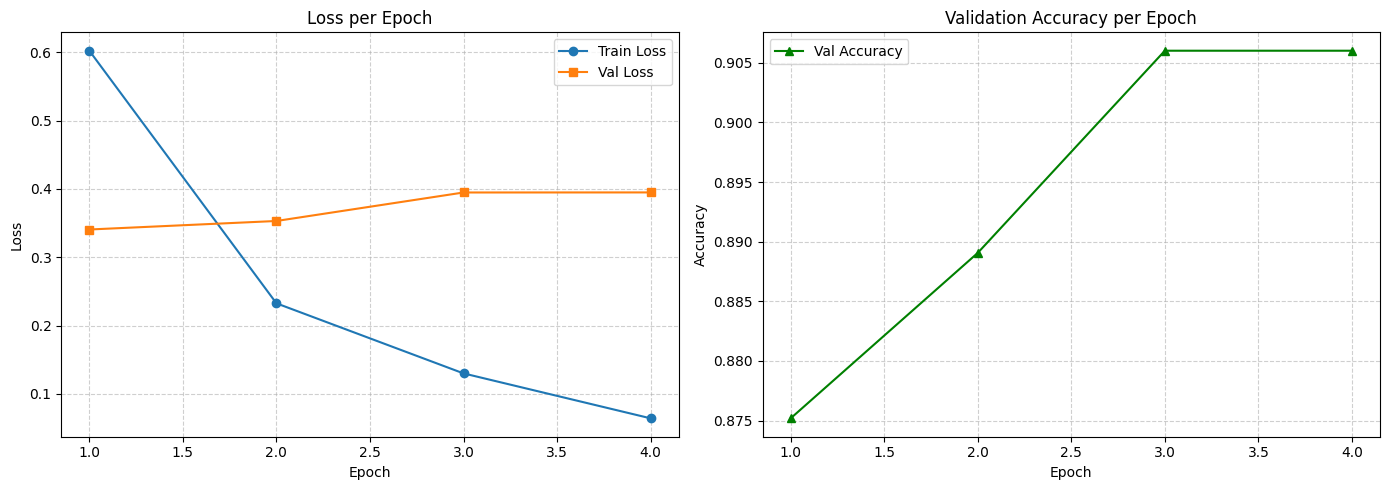

In [11]:
# ── Training ───────────────────────────────────────────────────────────────────
BEST_MODEL_PATH = "best_bert_sentiment.pt"
best_val_loss   = float("inf")
history         = {"train_loss": [], "val_loss": [], "val_acc": []}

print("Starting training...\n")

for epoch in range(1, EPOCHS + 1):
    print(f"── Epoch {epoch}/{EPOCHS} ──────────────────────────────")

    # Train
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE)

    # Validate on the test split after every epoch
    val_loss, val_acc, _, _ = evaluate(model, test_loader, DEVICE)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Val   Loss : {val_loss:.4f}")
    print(f"  Val   Acc  : {val_acc:.4f}")

    # Save the best model checkpoint based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  ✅ Best model saved (val_loss={best_val_loss:.4f})")

    print()

print("Training complete.")

# ── Plot training curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"],   marker="s", label="Val Loss")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].plot(epochs_range, history["val_acc"], marker="^", color="green", label="Val Accuracy")
axes[1].set_title("Validation Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

## 10. Evaluation on Test Set

In [12]:
# ── Load the best checkpoint ───────────────────────────────────────────────────
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
print(f"Loaded best model from '{BEST_MODEL_PATH}'\n")

# ── Run inference ──────────────────────────────────────────────────────────────
_, test_acc, y_pred, y_true = evaluate(model, test_loader, DEVICE)

# ── Compute metrics ────────────────────────────────────────────────────────────
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall    = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1        = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("═" * 45)
print("         TEST SET METRICS (macro avg)")
print("═" * 45)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("═" * 45)

# ── Detailed classification report ────────────────────────────────────────────
print("\nDetailed Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=LABEL_NAMES,
    zero_division=0,
))

Loaded best model from 'best_bert_sentiment.pt'

═════════════════════════════════════════════
         TEST SET METRICS (macro avg)
═════════════════════════════════════════════
  Accuracy  : 0.8752
  Precision : 0.7286
  Recall    : 0.7532
  F1-Score  : 0.7374
═════════════════════════════════════════════

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.75      0.67        52
     Neutral       0.64      0.57      0.60        90
    Positive       0.95      0.94      0.95       507

    accuracy                           0.88       649
   macro avg       0.73      0.75      0.74       649
weighted avg       0.88      0.88      0.88       649



## 11. Confusion Matrix Visualization

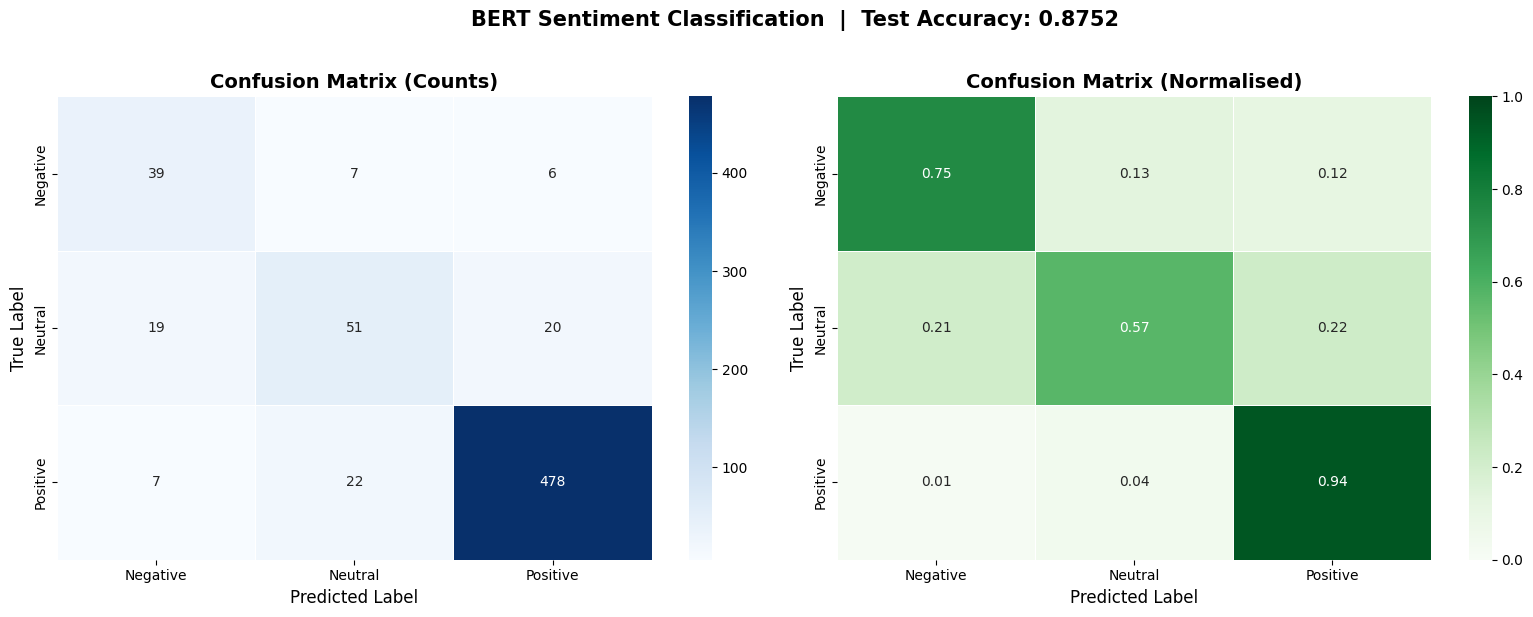

Confusion matrix saved to 'confusion_matrix.png'


In [13]:
# ── Raw counts ────────────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: raw counts ---
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    ax=axes[0],
    linewidths=0.5,
)
axes[0].set_title("Confusion Matrix (Counts)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Predicted Label", fontsize=12)
axes[0].set_ylabel("True Label", fontsize=12)

# --- Plot 2: row-normalised (recall per class) ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    ax=axes[1],
    vmin=0,
    vmax=1,
    linewidths=0.5,
)
axes[1].set_title("Confusion Matrix (Normalised)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Predicted Label", fontsize=12)
axes[1].set_ylabel("True Label", fontsize=12)

plt.suptitle(
    f"BERT Sentiment Classification  |  Test Accuracy: {accuracy:.4f}",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Confusion matrix saved to 'confusion_matrix.png'")